In [ ]:
###DISTANCE DATA
import pandas as pd
files = ['raw_data_amide.csv', 'raw_data_gna.csv', 'raw_data_unmod.csv']
for file in files:
    df = pd.read_csv(file)
    if 'unmod' in file:
        df['comp_name'] = df['comp_name'].str.replace('.pdb', '', regex=False)
    suffix = file.split('_')[2].split('.')[0]
    df['comp_name'] = df['comp_name'] + '_' + suffix
    new_file = file.split('.')[0] + '1.csv'
    df.to_csv(new_file, index=False)
import pandas as pd
files = ['raw_data_amide1.csv', 'raw_data_gna1.csv', 'raw_data_unmod1.csv']
dfs = [pd.read_csv(file) for file in files]
combined_df = pd.concat(dfs).sort_values(by='comp_name')

numeric_df = combined_df.select_dtypes(include='number')
averages = numeric_df.mean()
print(averages)

original_columns = combined_df.columns
numeric_df = combined_df.select_dtypes(include='number')
columns_to_drop = numeric_df.columns[numeric_df.mean() == 0]
combined_df.drop(columns=columns_to_drop, inplace=True)
dropped_count = len(columns_to_drop)
print(f'Dropped columns: {dropped_count}')

combined_df.columns = range(combined_df.shape[1])
combined_df.insert(0, 'comp_name', combined_df.pop(0))

print(combined_df.head(2))
print(combined_df.shape)

###(28509, 801)
combined_df.to_csv('raw_data_distances.csv', index=False)

In [ ]:
## CORRECTS FINGERPRINTS CSV FILES
fingerprints = pd.read_csv('rdkit/fingerprints_output.csv')
fingerprints['File'] = fingerprints['File'].str.replace('.pdb', '', regex=False)
fingerprints['uint8_vector'] = fingerprints['uint8_vector'].str.strip('[]').apply(lambda x: list(map(int, x.split(','))))
uint8_expanded = fingerprints['uint8_vector'].apply(pd.Series)
fingerprints = fingerprints.drop('uint8_vector', axis=1).join(uint8_expanded)
fingerprints.columns = ['base'] + [f'uint8_{i}' for i in range(uint8_expanded.shape[1])]
fingerprints_full_data = fingerprints.dropna()
fingerprints_less_data = fingerprints[fingerprints.isnull().any(axis=1)]
print(fingerprints_full_data.head())
print(fingerprints_full_data.shape)
fingerprints_less_data = fingerprints_less_data.iloc[:, :-32]
print(fingerprints_less_data.head())
print(fingerprints_less_data.shape)

fingerprints_full_data.reset_index(drop=True, inplace=True)
fingerprints_less_data.reset_index(drop=True, inplace=True)
fingerprints_full_data.to_csv('rdkit/fp_corrected1.csv', index=False)
fingerprints_less_data.to_csv('rdkit/fp_corrected2.csv', index=False)

In [ ]:
## COLLECTING FP DATA CELL 1
import pandas as pd
df = pd.read_csv('raw_data_distances.csv')
df = df[['comp_name']]
print(df.head(10))
print(df.shape)

df_fp = pd.read_csv('rdkit/fp_corrected1.csv')
output = pd.DataFrame()

for comp in df['comp_name']:
    if 'amide' in comp:
        temp = df_fp.loc[df_fp['base'] == 'R3-R4'].copy()
    else:
        temp = df_fp.loc[df_fp['base'] == 'AG'].copy()
    temp.loc[:, 'comp_name'] = comp
    output = pd.concat([output, temp], ignore_index=True)

output.reset_index(drop=True, inplace=True)
output = output[['comp_name'] + [col for col in output.columns if col != 'comp_name' and col != 'base']]
print(output.head(10))
print(output.shape)

In [ ]:
## COLLECTING FP DATA CELL 2
import pandas as pd

fp_corrected = pd.read_csv('rdkit/fp_corrected2.csv')

gna_data = fp_corrected[fp_corrected['base'] == 'GNAU'].drop(columns='base').reset_index(drop=True)
u_data = fp_corrected[fp_corrected['base'] == 'U'].drop(columns='base').reset_index(drop=True)

new_columns = [f'uint8_{i}' for i in range(64, 64 + gna_data.shape[1])]
gna_data.columns = new_columns
u_data.columns = new_columns

gna_rows = output['comp_name'].str.contains('gna', case=False)

# Split the original output into two: one for 'gna' rows and one for non-'gna' rows
output_gna = output[gna_rows].reset_index(drop=True)
output_u = output[~gna_rows].reset_index(drop=True)

# Extend the gna and u data to match the rows of output_gna and output_u, respectively
gna_data = pd.concat([gna_data] * len(output_gna), ignore_index=True)
u_data = pd.concat([u_data] * len(output_u), ignore_index=True)

# Concatenate the extended data to the original output_gna and output_u dataframes
output_gna = pd.concat([output_gna, gna_data], axis=1)
output_u = pd.concat([output_u, u_data], axis=1)

# Combine both parts back into a single dataframe
output_combined = pd.concat([output_gna, output_u]).reset_index(drop=True)

print(output_combined.head(2))
print(output_combined.shape)
# [2 rows x 97 columns]
# (28509, 97)
output_combined.sort_values(by='comp_name', inplace=True)
output_combined.to_csv('raw_data_fp.csv', index=False)

In [ ]:
### FROM DUPLICATE DATA, FINDS THE ENTRY WITH HIGHEST MEAN COUNTS / RSD
import pandas as pd
data = pd.read_csv('/data/home/mrichte3/RNASeq/gene_alignments5.csv')
duplicates = data['target_rna'].value_counts()
duplicate_count = 0
for rna, count in duplicates.items():
    if count > 1:
        print(f"{rna}, {count}")
        duplicate_count += 1
print("Number of duplicates:", duplicate_count)
single_entries = data[data['target_rna'].duplicated(keep=False)][['target_rna', 'ensembl_id']].drop_duplicates()
print(len(single_entries))
print(single_entries)

lookup_data = pd.read_csv('/data/home/mrichte3/RNASeq/normalized_rawcounts_with_rsd.csv')
mean_values = []
rsd_values = []
for index, row in single_entries.iterrows():
    ensembl_id = row['ensembl_id']
    target_rna = row['target_rna']
    means = lookup_data[lookup_data['ensembl_id'] == ensembl_id][['mean_nt', 'mean_unmod', 'mean_amide', 'mean_gna']]
    rsds = lookup_data[lookup_data['ensembl_id'] == ensembl_id][['rsd_nt', 'rsd_unmod', 'rsd_amide', 'rsd_gna']]
    mean_of_means = means.mean(axis=1).mean() if not means.empty else None
    mean_of_rsds = rsds.mean(axis=1).mean() if not rsds.empty else None
    mean_values.append({'ensembl_id': ensembl_id, 'target_rna': target_rna, 'mean_of_means': mean_of_means})
    rsd_values.append({'ensembl_id': ensembl_id, 'target_rna': target_rna, 'mean_of_rsds': mean_of_rsds})
mean_df = pd.DataFrame(mean_values)
rsd_df = pd.DataFrame(rsd_values)
result = mean_df.merge(rsd_df, on=['ensembl_id', 'target_rna'])
print(result)

result['mean_ratio'] = result['mean_of_means'] / result['mean_of_rsds']
grouped = result.groupby('target_rna')
highest_means = grouped.apply(lambda x: x.loc[x['mean_ratio'].idxmax()])
output = highest_means[['ensembl_id', 'target_rna', 'mean_ratio']]
print(output)
print("Number of matches:", len(output))

output[['ensembl_id']].to_csv('duplicates_to_keep.csv', index=False)

In [39]:
### CHECKS TO MAKE SURE FINGERPRINTS MATCH GENE_ALIGNS
import pandas as pd
import numpy as np

def search_ecfp(raw_data_file, fingerprint_file):
    raw_df = pd.read_csv(raw_data_file)
    # raw_df = raw_df[:5]
    fp_df = pd.read_csv(fingerprint_file)
    fp_data = fp_df.iloc[:, 1:].values.astype(int)
    fp_length = fp_data.shape[1] # length of the fingerprints
    results = {}

    for index, row in raw_df.iterrows():
        comp_name = row['comp_name']
        # row_data = row[1:].values.astype(str)
        row_data = row[1:-1].values.astype(str)
        match_string = ""

        # print(f"Processing comp_name: {comp_name}")

        for i in range(0, len(row_data), fp_length): # Step through data by fingerprint length
            cell_data = row_data[i:i + fp_length]

            # print(f"Processing cell data: {cell_data}")
            try:
                cell_array = np.array([int(x) for x in cell_data]) #more robust int conversion
            except ValueError as e:
                # print(f"ValueError: {e}")
                match_string += "X"
                continue

            # print(f"Cell array: {cell_array}")
            match_found = False
            for base, fp_row in zip(fp_df['base'], fp_data):

                if np.array_equal(cell_array, fp_row):
                    # print(f"Match found: {base}")
                    match_string += base
                    match_found = True
                    break
            if not match_found:
                print("No match found")
                match_string += "X"

        results[comp_name] = match_string

    return results

results = search_ecfp('raw_data_3.csv', 'rdkit/no_h/fingerprints_output.csv')

results2 = []
for comp_name, matches in results.items():
    ensembl_id = comp_name.split('_')[0]
    target_rna = matches[-21:]
    results2.append((comp_name, ensembl_id, target_rna))
    # print(f"{comp_name}: {target_rna}, ensembl_id: {ensembl_id}")

for comp_name, ensembl_id, target_rna in results2:
    print(f"{comp_name}: {target_rna}, ensembl_id: {ensembl_id}")
    break
print(f"len results2 {len(results2)}")

import pandas as pd
gene_alignments = pd.read_csv('/data/home/mrichte3/RNASeq/gene_alignments3.csv')
for comp_name, ensembl_id, target_rna in results2:
    match = gene_alignments.loc[gene_alignments['ensembl_id'] == ensembl_id, 'target_rna']
    if match.empty:
        print(f"{comp_name}: No match found for ensembl_id: {ensembl_id}")
    elif match.values[0] != target_rna:
        print(comp_name)

ENSG00000000003_amide: CCAUAGGAAUAUGAAUUUCCA, ensembl_id: ENSG00000000003
len results2 32307


In [ ]:
### FINDS DUPLICATES TO REMOVE
import pandas as pd
data = pd.read_csv('/data/home/mrichte3/RNASeq/gene_alignments5.csv')
single_entries = data[data['target_rna'].duplicated(keep=False)][['target_rna', 'ensembl_id']].drop_duplicates()
print(len(single_entries))
print(single_entries)

duplicates_to_keep = pd.read_csv('duplicates_to_keep.csv')
single_entries = single_entries[~single_entries['ensembl_id'].isin(duplicates_to_keep['ensembl_id'])]
print(single_entries)
single_entries[['ensembl_id']].to_csv('duplicates_to_remove.csv', index=False)

In [3]:
## CODE TO REMOVE DUPLICATES
import pandas as pd

duplicates = pd.read_csv('duplicates_to_remove.csv')['ensembl_id'].tolist()

# for i in range(4):
#     df = pd.read_csv(f'raw_data_{i}.csv')
#     df = df[~df['comp_name'].str.split('_').str[0].isin(duplicates)]
#     df.to_csv(f'raw_data_{i}_cleaned.csv', index=False)
df = pd.read_csv(f'raw_data_1.csv')
df = df[~df['comp_name'].str.split('_').str[0].isin(duplicates)]
df.to_csv(f'raw_data_1_cleaned.csv', index=False)

In [47]:
#############CREATING FPS FROM ENCODINGS BELOW: raw_data_3.csv
import csv
key_mapping = {1: ["A", 0, 0, 0, 0, 1, 4, 0, 0, 64, 0, 192, 0, 40, 0, 128, 32, 64, 0, 144, 192, 137, 8, 81, 9, 0, 25, 0, 0, 64, 64, 0, 16], 2: ["C", 0, 0, 0, 0, 1, 4, 0, 35, 64, 4, 192, 1, 40, 0, 128, 32, 64, 32, 144, 192, 1, 0, 65, 1, 0, 25, 2, 0, 64, 64, 0, 16], 3: ["G", 0, 0, 0, 0, 1, 4, 0, 33, 64, 0, 192, 32, 40, 0, 128, 32, 64, 32, 144, 192, 137, 8, 65, 73, 0, 25, 64, 0, 64, 66, 0, 16], 4: ["U", 0, 0, 0, 0, 1, 4, 0, 32, 64, 4, 192, 32, 40, 0, 128, 0, 64, 32, 128, 192, 1, 0, 1, 1, 0, 25, 66, 0, 64, 64, 2, 16], 5: ["R3", 4, 0, 0, 4, 65, 132, 0, 0, 0, 0, 128, 36, 32, 0, 132, 0, 64, 10, 208, 130, 1, 0, 1, 1, 0, 65, 0, 0, 80, 64, 0, 24], 6: ["R4", 12, 0, 0, 0, 1, 128, 0, 0, 8, 0, 128, 32, 32, 0, 8, 0, 192, 10, 152, 130, 129, 0, 0, 0, 0, 1, 0, 2, 16, 72, 0, 24], 7: ["GNAU", 64, 0, 0, 0, 1, 4, 0, 0, 0, 0, 128, 32, 0, 0, 2, 0, 32, 0, 8, 3, 1, 0, 1, 1, 0, 192, 0, 0, 82, 68, 2, 16]}


csv_rows = []

with open('raw_data_2.csv', 'r') as file:
    reader = csv.DictReader(file)
    rna_columns = [f'rna{i}' for i in range(1, 43)]
    for row in reader:
        comp_name = row['comp_name']
        log2FC = row['log2FC']
        mapped_values = []
        for rna in rna_columns:
            rna_value = int(row[rna])
            rna_key_mapping = key_mapping[rna_value]
            mapped_values.append(rna_key_mapping)
        output = ','.join(','.join(map(str, value[1:])) for value in mapped_values)
        csv_row = f"{comp_name},{output},{log2FC}"
        csv_rows.append(csv_row)


i = 0
for row in csv_rows:
    print(row)
    i = i + 1
    if i == 2:
        break
###############################

data = [row.split(',') for row in csv_rows]
columns = ['comp_name'] + [f'fp{i}' for i in range(len(data[0]) - 2)] + ['log2FC']
df = pd.DataFrame(data, columns=columns)

print(df.head(2))
print(df.shape)
df.to_csv('raw_data_3.csv', index=False)

               comp_name fp0 fp1 fp2 fp3 fp4 fp5 fp6 fp7 fp8  ... fp1335  \
0  ENSG00000000003_amide   0   0   0   0   1   4   0   0  64  ...      9   
1    ENSG00000000003_gna   0   0   0   0   1   4   0   0  64  ...      9   

  fp1336 fp1337 fp1338 fp1339 fp1340 fp1341 fp1342 fp1343               log2FC  
0      0     25      0      0     64     64      0     16  -0.1571126435579587  
1      0     25      0      0     64     64      0     16  -0.1364120106308341  

[2 rows x 1346 columns]
(33549, 1346)


In [15]:
## KEY FOR ENCODING GUIDE STRAND
import pandas as pd
data = pd.read_csv('raw_data_1.csv')
data = data[['comp_name', 'log2FC']]

encoding_key = {
    'unmod': '141331442141441331314',
    'amide': '145631442141441331314',
    'gna': '141331742141441331314'
}

for i in range(21):
    data[f'rna{i+1}'] = None

for index, row in data.iterrows():
    encoding_value = None
    for key in encoding_key:
        if key in row['comp_name']:
            encoding_value = encoding_key[key]
            break
    if encoding_value:
        for i in range(21):
            data.at[index, f'rna{i+1}'] = encoding_value[i]

print(data.head())
print(data.shape)

               comp_name    log2FC rna1 rna2 rna3 rna4 rna5 rna6 rna7 rna8  \
0  ENSG00000000003_amide -0.157113    1    4    5    6    3    1    4    4   
1    ENSG00000000003_gna -0.136412    1    4    1    3    3    1    7    4   
2  ENSG00000000003_unmod -0.255741    1    4    1    3    3    1    4    4   
3  ENSG00000000419_amide  0.110902    1    4    5    6    3    1    4    4   
4    ENSG00000000419_gna  0.191055    1    4    1    3    3    1    7    4   

   ... rna12 rna13 rna14 rna15 rna16 rna17 rna18 rna19 rna20 rna21  
0  ...     1     4     4     1     3     3     1     3     1     4  
1  ...     1     4     4     1     3     3     1     3     1     4  
2  ...     1     4     4     1     3     3     1     3     1     4  
3  ...     1     4     4     1     3     3     1     3     1     4  
4  ...     1     4     4     1     3     3     1     3     1     4  

[5 rows x 23 columns]
(33558, 23)


In [3]:
## TESTING FP GENERATION FROM PDB
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.DataStructs import FingerprintSimilarity

def calculate_fingerprint_from_pdb(pdb_file):
    mol = Chem.MolFromPDBFile(pdb_file)
    nBits = 10240  # Large fingerprint size
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=20, fpSize=nBits)

    if mol is None:
        return None

    fp = generator.GetFingerprint(mol)
    return fp

# Define the PDB files for oligonucleotides
files = ["unmod_oligo.pdb", "gna_oligo.pdb", "amide_oligo.pdb"]
fingerprints = {}

for file in files:
    pdb_file = f"rdkit/{file}"  # Update this path according to your directory structure
    fingerprints[file] = calculate_fingerprint_from_pdb(pdb_file)



if len(fingerprints) == 3:
    data_matrix = np.array([np.array(list(map(int, fp))) for fp in fingerprints.values()])
    positions_all_zero = np.all(data_matrix == 0, axis=0).sum()
    positions_all_one = np.all(data_matrix == 1, axis=0).sum()
    total_length = data_matrix.shape[1]
    print(f"Number of positions where all fingerprints are 0: {positions_all_zero}")
    print(f"Number of positions where all fingerprints are 1: {positions_all_one}")
    print(f"Total character length of fingerprints: {total_length}")
else:
    print("Expected three fingerprints, but found fewer.")

Number of positions where all fingerprints are 0: 8512
Number of positions where all fingerprints are 1: 116
Total character length of fingerprints: 10240


In [ ]:
# SHOWS COMMON 0 POSITIONS, WHERE ALL 3 HAVE A 0
import matplotlib.pyplot as plt

if len(fingerprints) == 3:
    data_matrix = np.array([np.array(list(map(int, fp))) for fp in fingerprints.values()])
    not_all_zero = np.any(data_matrix != 0, axis=0).astype(int)
    
    reversed_data = 1 - not_all_zero
    
    plt.figure(figsize=(15, 2))
    plt.imshow(reversed_data.reshape(1, -1), cmap='gray', aspect='auto', interpolation='nearest')
    plt.xticks(np.arange(0, reversed_data.shape[0], step=1000), labels=[])  # Show ticks without labels
    plt.yticks([])
    plt.axis('on')  # Keep the x-axis visible
    plt.show()
else:
    print("Expected three fingerprints, but found fewer.")

In [ ]:
# SHOWS 1 POSITIONS
import matplotlib.pyplot as plt
import numpy as np

if len(fingerprints) == 3:
    data_matrix = np.array([np.array(list(map(int, fp))) for fp in fingerprints.values()])
    for i in range(data_matrix.shape[0]):
        zero_positions = (data_matrix[i] == 0).astype(int)
        # reversed_data = 1 - zero_positions
        reversed_data = zero_positions
        
        plt.figure(figsize=(15, 2))
        plt.imshow(reversed_data.reshape(1, -1), cmap='gray', aspect='auto', interpolation='nearest')
        plt.xticks(np.arange(0, reversed_data.shape[0], step=1000), labels=[])
        plt.yticks([])
        plt.title(files[i])
        plt.axis('on')
        plt.show()
else:
    print("Expected three fingerprints, but found fewer.")

In [ ]:
## FINAL CODE FOR GENERATING FP FROM PDB
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.DataStructs import FingerprintSimilarity
import numpy as np

def convert_to_uint8(bit_vector):
    # Convert the bit vector to a list of integers
    bits = list(bit_vector)
    # Pad the list to ensure it is a multiple of 8
    while len(bits) % 8 != 0:
        bits.append(0)
    # Convert chunks of 8 bits to uint8
    uint8_vector = np.packbits(bits)
    return uint8_vector

def calculate_fingerprint_from_pdb(pdb_file, nBits=256, radius=1):
    mol = Chem.MolFromPDBFile(pdb_file)
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=nBits)

    if mol is None:
        return None

    fp = generator.GetFingerprint(mol)
    return fp


files = ["U.pdb", "A.pdb", "C.pdb", "G.pdb", "GNAU.pdb", "R3.pdb", "R4.pdb"]

fingerprints = {}

for file in files:
    pdb_file = f"rdkit/no_h/{file}"
    if file in ["AG.pdb", "R3-R4.pdb"]:
        fingerprints[file] = calculate_fingerprint_from_pdb(pdb_file, nBits=512, radius=2)
    else:
        fingerprints[file] = calculate_fingerprint_from_pdb(pdb_file)
    # print(f"{file}: {list(map(int, fingerprints[file]))}")

# if len(fingerprints) > 0:
#     for file, fp in fingerprints.items():
#         print(f"{file}: {np.sum(np.array(fp) == 1)} ones, {np.sum(np.array(fp) == 0)} zeros")
# else:
#     print("No fingerprints found.")

# # SHOWS 1 POSITIONS
# # MATRIX DOESN'T WORK WITH DIFFERENT SIZES
# import matplotlib.pyplot as plt
# import numpy as np

# if len(fingerprints) > 0:
#     data_matrix = np.array([np.array(list(map(int, fp))) for fp in fingerprints.values()])
#     for i in range(data_matrix.shape[0]):
#         zero_positions = (data_matrix[i] == 0).astype(int)
#         # reversed_data = 1 - zero_positions
#         reversed_data = zero_positions
        
#         plt.figure(figsize=(15, 2))
#         plt.imshow(reversed_data.reshape(1, -1), cmap='gray', aspect='auto', interpolation='nearest')
#         plt.xticks(np.arange(0, reversed_data.shape[0], step=5), labels=[])
#         plt.yticks([])
#         plt.title(files[i])
#         plt.axis('on')
#         plt.show()
# else:
#     print("Expected three fingerprints, but found fewer.")

if len(fingerprints) > 0:
    for file, fp in fingerprints.items():
        uint8_vector = convert_to_uint8(fp)
        print(f"{file} uint8_vector: {uint8_vector}")
else:
    print("No fingerprints found.")
##U 8
##A 5
##obj05 is U with no protons. 06 and 04 are same U
##obj06 is U with proton. 10 protons
##obj08 is A modified with nitrogen to O (from obj07)

# import pandas as pd

# output_data = []
# if len(fingerprints) > 0:
#     for file, fp in fingerprints.items():
#         uint8_vector = convert_to_uint8(fp)
#         output_data.append([file, list(uint8_vector)])

# df = pd.DataFrame(output_data, columns=["File", "uint8_vector"])
# df.to_csv("rdkit/no_h/fingerprints_output.csv", index=False)

output_data = []
if fingerprints:
    base = "base"
    header = [base] + [f"ecfp{i}" for i in range(len(convert_to_uint8(next(iter(fingerprints.values())))))]
    output_data.append(header)
    for file, fp in fingerprints.items():
        uint8_vector = convert_to_uint8(fp)
        output_data.append([file.rsplit('.', 1)[0]] + list(uint8_vector))
df = pd.DataFrame(output_data[1:], columns=output_data[0])
print(df)
df.to_csv("rdkit/no_h/fingerprints_output.csv", index=False, header=True)

In [2]:
## AMINE FP
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import numpy as np
import pandas as pd

def convert_to_uint8(bit_vector):
    bits = list(bit_vector)
    while len(bits) % 8 != 0:
        bits.append(0)
    uint8_vector = np.packbits(bits)
    return uint8_vector

def calculate_fingerprint_from_pdb(pdb_file, nBits=512, radius=2):
    mol = Chem.MolFromPDBFile(pdb_file)
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=nBits)
    if mol is None:
        return None
    fp = generator.GetFingerprint(mol)
    return fp

pdb_file = "rdkit/Amine.pdb"
fingerprint = calculate_fingerprint_from_pdb(pdb_file)

if fingerprint:
    uint8_vector = convert_to_uint8(fingerprint)
    header = ["base"] + [f"ecfp{i}" for i in range(len(uint8_vector))]
    data = [["Amine"] + list(uint8_vector)]
    df = pd.DataFrame(data, columns=header)
    df.to_csv("rdkit/amine_fp.csv", index=False, header=True)


In [6]:
import pandas as pd
df = pd.read_csv('raw_data_4b.csv')
replacement_df = pd.read_csv('rdkit/amine_fp.csv')
replacement_values = replacement_df.iloc[0, 1:65].values
mask = df['comp_name'].str.contains('amide', case=False, na=False)
uint8_columns = [f'uint8_{i}' for i in range(64)]
df.loc[mask, uint8_columns] = replacement_values
df = df.loc[mask].drop(columns=['log2FC', 'off_target'])
df.to_csv('raw_data_5_amine.csv', index=False)


In [4]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import numpy as np

def convert_to_uint8(bit_vector):
    bits = list(bit_vector)
    while len(bits) % 8 != 0:
        bits.append(0)
    return np.packbits(bits)

def calculate_fingerprint_from_pdb(pdb_file, nBits=256, radius=1):
    mol = Chem.MolFromPDBFile(pdb_file, removeHs=False)
    if mol is None:
        raise ValueError(f"Could not load {pdb_file}")
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=nBits)
    return generator.GetFingerprint(mol)

# File paths
all_carbon_file = "rdkit/no_h/allcarbon_reorder.pdb"
g_file = "rdkit/no_h/G_reorder.pdb"
temp_file = "rdkit/no_h/temp_all_carbon.pdb"

# Read `G.pdb` lines for replacements
with open(g_file, "r") as g_f:
    g_lines = g_f.readlines()

# Read `all_carbon.pdb` for modifications
with open(all_carbon_file, "r") as all_f:
    all_carbon_lines = all_f.readlines()

# Calculate and print fingerprint for initial `all_carbon.pdb`
fp = calculate_fingerprint_from_pdb(all_carbon_file)
print(f"Initial Fingerprint (all atoms carbon): {convert_to_uint8(fp)}")

# Progressively replace lines and calculate fingerprints
modified_lines = all_carbon_lines[:]  # Start with all-carbon structure
for i in range(len(g_lines)):
    # Skip non-atom lines
    if not g_lines[i].startswith("ATOM"):
        continue

    # Replace the line in the progressively modified structure
    modified_lines[i] = g_lines[i]

    # Write updated structure to the temp file
    with open(temp_file, "w") as temp_f:
        temp_f.writelines(modified_lines)

    # Calculate fingerprint for updated structure
    fp = calculate_fingerprint_from_pdb(temp_file)
    print(f"Fingerprint after progressively replacing up to line {i + 1}: {convert_to_uint8(fp)}")

    # Break after the second iteration
    if i + 1 == 2:
        break


Initial Fingerprint (all atoms carbon): [ 64   8   0  20  64   4   1   0 144   0 128   4   0   2   0   8   0   0
   0   2   0   0   0   0   0   0   0   0  48   0   0  16]
Fingerprint after progressively replacing up to line 1: [ 64   8   0  20  64   4   0   0 144   0 128   4   0 130   0 136   0   0
   0   2   0   0   0   0   0  16   0   0  48   0   0  16]
Fingerprint after progressively replacing up to line 2: [  0   8   0   4  64   4   0   0 144   0 128   4   0   2   0   8   0   0
   0   2   0   0   2   0   1  24   0   0  32   0   0  16]


In [12]:
from pymol import cmd

cmd.load("rdkit/no_h/G.pdb", "G")
cmd.alter("G", "elem = 'C'; name = 'C'")
cmd.alter("G", "formal_charge = 0")
cmd.sort()
cmd.save("rdkit/no_h/all_carbon.pdb", "G")


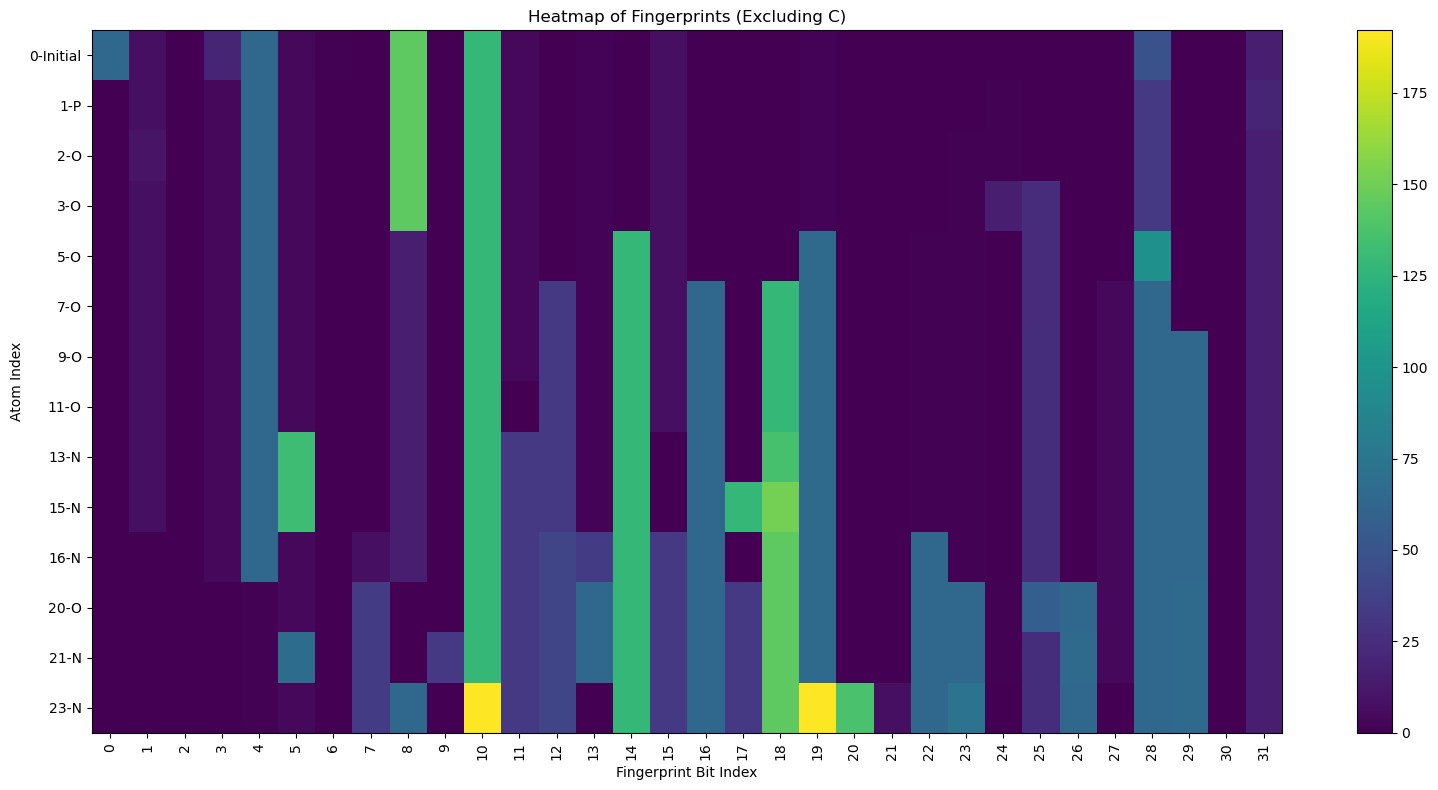

In [1]:
#### HEATMAP ORIGINAL ORDER
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the data from the file
data_path = 'rdkit/no_h/data.txt'

# Process the file into a DataFrame
fingerprints = {}
current_key = None
current_values = []

with open(data_path, 'r') as f:
    for line in f:
        if "Fingerprint" in line:  # Start of a new fingerprint
            if current_key:  # Save the previous fingerprint
                fingerprints[current_key] = np.array(current_values)
            current_key, values = line.split(':')
            current_key = current_key.strip()
            current_values = [int(x) for x in values.strip().strip("[]").split()]
        elif current_key:  # Continuation of the current fingerprint
            current_values.extend([int(x) for x in line.strip().strip("[]").split()])
    if current_key:  # Save the last fingerprint
        fingerprints[current_key] = np.array(current_values)

# Convert to a DataFrame
df = pd.DataFrame(fingerprints).T

# Define atom indices and names for G.pdb
atom_indices = [0] + list(range(1, 24))  # Include 0 for the initial fingerprint
atom_names = [
    "P", "O", "O", "C", "O", "C", "O", "C", "O", "C",
    "O", "C", "N", "C", "N", "N", "C", "C", "C", "O",
    "N", "C", "N"
]

# Filter rows where atom_names != "C"
rows_to_keep = [i for i in range(len(atom_names) + 1) if i == 0 or atom_names[i - 1] != "C"]
df_filtered = df.iloc[rows_to_keep]
atom_indices_filtered = [atom_indices[i] for i in rows_to_keep]
atom_names_filtered = [atom_names[i - 1] for i in rows_to_keep if i > 0]

# Combine index and atom name for y-axis labels
y_labels = [f"{index}-{name}" for index, name in zip(atom_indices_filtered, ["Initial"] + atom_names_filtered)]

# Calculate differences compared to the initial fingerprint
initial_fp = df.iloc[0].values
differences = df_filtered.apply(lambda row: row != initial_fp, axis=1)

# Create the heatmap
plt.figure(figsize=(16, 8))
plt.imshow(df_filtered.values, aspect='auto', cmap='viridis')
# plt.colorbar(label="Fingerprint Value")
plt.colorbar(label="")
plt.title("Heatmap of Fingerprints (Excluding C)")

# Set y-axis labels with combined index and atom name
y_ticks = np.arange(0, len(df_filtered.index))
plt.yticks(ticks=y_ticks, labels=y_labels)
plt.ylabel("Atom Index")

# Ensure all x-axis labels for 32 positions
x_ticks = np.arange(0, df_filtered.shape[1])
plt.xticks(ticks=x_ticks, labels=x_ticks, rotation=90)
plt.xlabel("Fingerprint Bit Index")

plt.tight_layout()
plt.show()


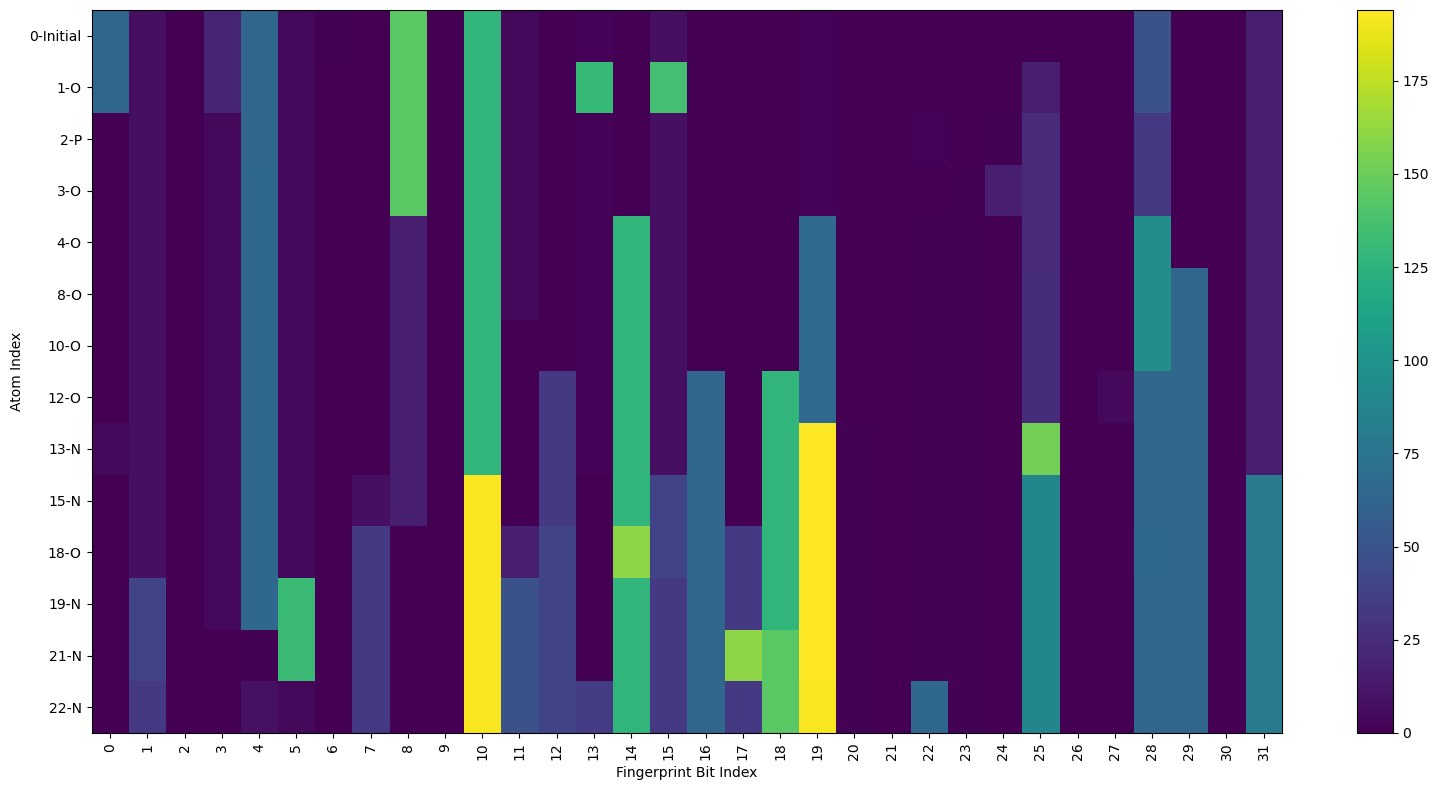

In [5]:
### HEATMAP REORDER
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the data from the file
data_path = 'rdkit/no_h/data.txt'

# Process the file into a DataFrame
fingerprints = {}
current_key = None
current_values = []

with open(data_path, 'r') as f:
    for line in f:
        if "Fingerprint" in line:  # Start of a new fingerprint
            if current_key:  # Save the previous fingerprint
                fingerprints[current_key] = np.array(current_values)
            current_key, values = line.split(':')
            current_key = current_key.strip()
            current_values = [int(x) for x in values.strip().strip("[]").split()]
        elif current_key:  # Continuation of the current fingerprint
            current_values.extend([int(x) for x in line.strip().strip("[]").split()])
    if current_key:  # Save the last fingerprint
        fingerprints[current_key] = np.array(current_values)

# Convert to a DataFrame
df = pd.DataFrame(fingerprints).T

# Define atom indices and names for G.pdb
atom_indices = [0] + list(range(1, 24))  # Include 0 for the initial fingerprint
atom_names = [    "O", "P", "O", "O", "C", "C", "C", "O", "C", "O",    "C", "O", "N", "C", "N", "C", "C", "O", "N", "C",    "N", "N", "C"]


# Filter rows where atom_names != "C"
rows_to_keep = [i for i in range(len(atom_names) + 1) if i == 0 or atom_names[i - 1] != "C"]
df_filtered = df.iloc[rows_to_keep]
atom_indices_filtered = [atom_indices[i] for i in rows_to_keep]
atom_names_filtered = [atom_names[i - 1] for i in rows_to_keep if i > 0]

# Combine index and atom name for y-axis labels
y_labels = [f"{index}-{name}" for index, name in zip(atom_indices_filtered, ["Initial"] + atom_names_filtered)]

# Calculate differences compared to the initial fingerprint
initial_fp = df.iloc[0].values
differences = df_filtered.apply(lambda row: row != initial_fp, axis=1)

# Create the heatmap
plt.figure(figsize=(16, 8))
plt.imshow(df_filtered.values, aspect='auto', cmap='viridis')
# plt.colorbar(label="Fingerprint Value")
plt.colorbar(label="")
# plt.title("Heatmap of Fingerprints (Excluding C)")

# Set y-axis labels with combined index and atom name
y_ticks = np.arange(0, len(df_filtered.index))
plt.yticks(ticks=y_ticks, labels=y_labels)
plt.ylabel("Atom Index")

# Ensure all x-axis labels for 32 positions
x_ticks = np.arange(0, df_filtered.shape[1])
plt.xticks(ticks=x_ticks, labels=x_ticks, rotation=90)
plt.xlabel("Fingerprint Bit Index")

plt.tight_layout()
plt.show()
